# Видео модели

Пайплайн: **Видео → детекция лиц (MediaPipe) → backbone → темпоральная агрегация → классификация эмоции**

Сравниваются **два backbone** × **три темпоральных агрегатора** = **6 моделей** на датасете **RAVDESS** (full-AV видео, 8 эмоций, 24 актёра):

| # | Backbone | Агрегация |
|---|---|---|
| 1–3 | MobileNetV3-Small (dim=576, ~3.6 MB) | BiGRU / BiLSTM / TCN |
| 4–6 | EmotiEffNet (dim=1280, ~15 MB) | BiGRU / BiLSTM / TCN |

Метрики: **Качество** (Accuracy, F1 macro) · **Скорость инференса** · **Размер пайплайна**

In [1]:
import os, io, time, gc, warnings
warnings.filterwarnings("ignore")

import cv2
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import torchvision.models as models
import torchvision.transforms as T
from torchvision.transforms import v2 as T2

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report,
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

SR = 16_000
N_MELS, MAX_LEN, HOP = 64, 128, 512
IMG_SIZE = 224
N_FRAMES = 16
results = []

EMOTION_MAP = {
    1: "neutral", 2: "calm", 3: "happy", 4: "sad",
    5: "angry", 6: "fearful", 7: "disgust", 8: "surprised",
}
N_CLASSES = len(EMOTION_MAP)


def pytorch_size_mb(model):
    b = sum(p.numel() * p.element_size() for p in model.parameters())
    b += sum(x.numel() * x.element_size() for x in model.buffers())
    return b / 1024 ** 2


CKPT_DIR = os.path.join("..", "trained_models", "video_emotion")
os.makedirs(CKPT_DIR, exist_ok=True)


def save_state_dict(name, module):
    """Сохраняем чекпоинт сразу после обучения, чтобы освободить MPS."""
    path = os.path.join(CKPT_DIR, f"{name}.pt")
    cpu_state = {k: v.detach().cpu().clone() for k, v in module.state_dict().items()}
    torch.save(cpu_state, path)
    print(f"Saved {path}")


def free_mps():
    """Полная очистка MPS: gc + два прохода empty_cache."""
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
        torch.mps.synchronize()
        torch.mps.empty_cache()


def chunked_eval(model, x_cpu, device, batch_size=64):
    """Прогон model.argmax по батчам с CPU — не аллоцирует на MPS активации
    для всего набора (важно после K=3 аугментации, когда train ×4)."""
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, x_cpu.size(0), batch_size):
            xb = x_cpu[i : i + batch_size].to(device)
            preds.append(model(xb).argmax(1).cpu())
            del xb
    return torch.cat(preds).numpy()


Device: mps


## 1. Загрузка видео-данных RAVDESS

In [2]:
RAVDESS_PATH = "../datasets/ravdess/"

video_paths, emo_labels, actor_ids = [], [], []

for d in sorted(os.listdir(RAVDESS_PATH)):
    if not d.startswith("Video_Speech_Actor_"):
        continue
    actor_dir = os.path.join(RAVDESS_PATH, d)
    for actor_sub in sorted(os.listdir(actor_dir)):
        if not actor_sub.startswith("Actor_"):
            continue
        actor_path = os.path.join(actor_dir, actor_sub)
        for f in sorted(os.listdir(actor_path)):
            if not f.endswith(".mp4"):
                continue
            parts = f.replace(".mp4", "").split("-")
            modality = int(parts[0])
            if modality != 1:
                continue
            emotion = int(parts[2])
            actor = int(parts[6])
            video_paths.append(os.path.join(actor_path, f))
            emo_labels.append(emotion - 1)
            actor_ids.append(actor)

emo_labels = np.array(emo_labels)
actor_ids = np.array(actor_ids)

unique_actors = sorted(set(actor_ids))
n_test_actors = max(1, len(unique_actors) // 5)
test_actors = set(unique_actors[-n_test_actors:])

train_idx = [i for i, a in enumerate(actor_ids) if a not in test_actors]
test_idx  = [i for i, a in enumerate(actor_ids) if a in test_actors]

train_videos = [video_paths[i] for i in train_idx]
test_videos  = [video_paths[i] for i in test_idx]
y_train = emo_labels[train_idx]
y_test  = emo_labels[test_idx]

print(f"Всего видео (full-AV speech): {len(video_paths)}")
for emo_id, name in EMOTION_MAP.items():
    print(f"  {name}: {(emo_labels == emo_id - 1).sum()}")
print(f"\nSpeaker-independent split (20 % актёров => test):")
print(f"  Train: {len(train_videos)} видео ({len(unique_actors) - n_test_actors} актёров)")
print(f"  Test:  {len(test_videos)} видео ({n_test_actors} актёров)")

Всего видео (full-AV speech): 1440
  neutral: 96
  calm: 192
  happy: 192
  sad: 192
  angry: 192
  fearful: 192
  disgust: 192
  surprised: 192

Speaker-independent split (20 % актёров => test):
  Train: 1200 видео (20 актёров)
  Test:  240 видео (4 актёров)


## 2. Предобработка: детекция лиц и извлечение признаков

**Стадия 1** — MediaPipe FaceDetector (`blaze_face_short_range`): обнаружение bounding box лица → обрезка → resize до 224×224  
**Стадия 2** — два backbone сравниваются:
- **MobileNetV3-Small** (dim=576, ~3.6 MB) — лёгкий мобильный backbone (ImageNet)
- **EmotiEffNet** (dim=1280, ~15 MB) — EfficientNet-B0, дообученный на AffectNet для распознавания эмоций

In [3]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

_DETECTOR_PATH = "../raw_models/blaze_face_short_range.tflite"
_face_detector = mp_vision.FaceDetector.create_from_options(
    mp_vision.FaceDetectorOptions(
        base_options=mp_python.BaseOptions(model_asset_path=_DETECTOR_PATH),
        min_detection_confidence=0.5,
    )
)

imagenet_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Аугментации применяются ко всему клипу как тензору (T,3,H,W) uint8 —
# torchvision разделяет одни и те же случайные параметры между всеми кадрами,
# что критично для темпоральной агрегации.
clip_aug = T2.Compose([
    T2.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1), antialias=True),
    T2.RandomHorizontalFlip(p=0.5),
    T2.RandomApply([T2.ColorJitter(0.2, 0.2, 0.2)], p=0.8),
    T2.RandomApply([T2.GaussianBlur(3, sigma=(0.1, 1.0))], p=0.3),
])
clip_erase = T2.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0)


def augment_clip(crops_uint8):
    """list[N_FRAMES] of np.uint8 (H,W,3) -> list[N_FRAMES] of np.uint8 (H,W,3).
    Все кадры одного клипа аугментируются одним набором случайных параметров."""
    clip = torch.from_numpy(np.stack(crops_uint8)).permute(0, 3, 1, 2)  # (T,3,H,W) uint8
    clip = clip_aug(clip)
    return [c.permute(1, 2, 0).numpy() for c in clip]


def extract_frames(video_path, n_frames=8):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return []
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames


def detect_and_crop_face(frame, target_size=IMG_SIZE):
    """MediaPipe FaceDetector => bbox crop => resize. Falls back to center crop."""
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    result = _face_detector.detect(mp_img)
    if result.detections:
        bb = result.detections[0].bounding_box
        h, w = frame.shape[:2]
        pad_x = int(bb.width * 0.1)
        pad_y = int(bb.height * 0.1)
        x1 = max(0, bb.origin_x - pad_x)
        y1 = max(0, bb.origin_y - pad_y)
        x2 = min(w, bb.origin_x + bb.width + pad_x)
        y2 = min(h, bb.origin_y + bb.height + pad_y)
        if x2 > x1 and y2 > y1:
            return cv2.resize(frame[y1:y2, x1:x2], (target_size, target_size))
    h, w = frame.shape[:2]
    s = min(h, w)
    y1, x1 = (h - s) // 2, (w - s) // 2
    return cv2.resize(frame[y1:y1 + s, x1:x1 + s], (target_size, target_size))


def extract_face_crops(video_list, n_frames=N_FRAMES):
    """Stage 1: video => sampled frames => face detection => list of crops per video."""
    all_crops = []
    for vp in tqdm(video_list, desc="Face detection"):
        frames = extract_frames(vp, n_frames)
        if not frames:
            crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * n_frames
        else:
            while len(frames) < n_frames:
                frames.append(frames[-1])
            crops = [detect_and_crop_face(f) for f in frames[:n_frames]]
        all_crops.append(crops)
    return all_crops  # List[List[np.ndarray(H,W,3)]], len = n_videos


print("Утилиты загружены ✓")


Утилиты загружены ✓


I0000 00:00:1778189566.019313 27535015 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778189566.021254 27535019 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [4]:
# ── Стадия 1: Детекция лиц => обрезка => resize 224×224 ────────────────────────
print("Стадия 1: Детекция лиц (MediaPipe)...")
train_crops = extract_face_crops(train_videos)
test_crops  = extract_face_crops(test_videos)
print(f"Train (orig): {len(train_crops)} видео × {N_FRAMES} кропов")
print(f"Test:         {len(test_crops)} видео × {N_FRAMES} кропов")

# ── Стадия 1b: Offline-аугментация обучающего набора (K=3 копии) ───────────────
AUG_COPIES = 3
torch.manual_seed(SEED); np.random.seed(SEED)

train_crops_orig = train_crops
y_train_orig = y_train
train_crops_aug = list(train_crops_orig)
y_train_aug = list(y_train_orig)
erase_flags = [False] * len(train_crops_orig)
for k in range(AUG_COPIES):
    for crops, lbl in tqdm(
        list(zip(train_crops_orig, y_train_orig)),
        desc=f"Аугментация кропов (копия {k+1}/{AUG_COPIES})",
    ):
        train_crops_aug.append(augment_clip(crops))
        y_train_aug.append(lbl)
        erase_flags.append(True)

train_crops = train_crops_aug
y_train = np.asarray(y_train_aug, dtype=y_train_orig.dtype)
assert len(train_crops) == (1 + AUG_COPIES) * len(train_crops_orig)
assert len(y_train) == len(train_crops)
print(
    f"Train после аугментации: {len(train_crops)} клипов "
    f"({1 + AUG_COPIES}× оригинала)."
)

# ── Стадия 2: MobileNetV3-Small => признаковые векторы ────────────────────────
mobilenet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
FEAT_DIM = 576
mobilenet.classifier = nn.Identity()
mobilenet = mobilenet.to(device).eval()
mobilenet_mb = pytorch_size_mb(mobilenet)
print(f"\nСтадия 2: MobileNetV3-Small ({mobilenet_mb:.1f} MB, dim={FEAT_DIM})")

# Сохраняем backbone сразу — состояние не меняется в течение обучения голов.
save_state_dict("mobilenet_v3_small_backbone", mobilenet)


def extract_features(crops_list, apply_erase=None):
    """Stage 2: pre-cropped face images => MobileNetV3-Small feature vectors.
    apply_erase[i]=True => применить RandomErasing (cutout) к нормализованному
    тензору i-го клипа перед прогоном через backbone."""
    all_feats = []
    for i, crops in enumerate(tqdm(crops_list, desc="MobileNet features")):
        faces = torch.stack([imagenet_transform(c) for c in crops])  # (T,3,H,W) float
        if apply_erase is not None and apply_erase[i]:
            faces = clip_erase(faces)
        with torch.no_grad():
            feats = mobilenet(faces.to(device)).cpu()
        all_feats.append(feats)
    return torch.stack(all_feats)


train_vis = extract_features(train_crops, apply_erase=erase_flags)
test_vis  = extract_features(test_crops)
print(f"Train features: {train_vis.shape}  |  Test features: {test_vis.shape}")
free_mps()


Стадия 1: Детекция лиц (MediaPipe)...


Face detection: 100%|██████████| 240/240 [00:54<00:00,  4.44it/s]


Train (orig): 1200 видео × 16 кропов
Test:         240 видео × 16 кропов


Аугментация кропов (копия 3/3): 100%|██████████| 1200/1200 [00:23<00:00, 52.14it/s]


Train после аугментации: 4800 клипов (4× оригинала).

Стадия 2: MobileNetV3-Small (3.6 MB, dim=576)
Saved ../trained_models/video_emotion/mobilenet_v3_small_backbone.pt


MobileNet features: 100%|██████████| 240/240 [00:04<00:00, 52.40it/s]


Train features: torch.Size([4800, 16, 576])  |  Test features: torch.Size([240, 16, 576])


In [5]:
# ── Стадия 2b: EmotiEffNet (AffectNet) => признаковые векторы ──────────────
from emotiefflib.facial_analysis import EmotiEffLibRecognizer

_emotieff_rec = EmotiEffLibRecognizer(
    engine="torch", model_name="enet_b0_8_best_vgaf", device=str(device)
)
FEAT_DIM_EFF = 1280
emotieffnet = _emotieff_rec.model
emotieffnet_mb = pytorch_size_mb(emotieffnet)
print(f"\nСтадия 2b: EmotiEffNet/AffectNet ({emotieffnet_mb:.1f} MB, dim={FEAT_DIM_EFF})")

# Сохраняем backbone сразу — состояние не меняется в течение обучения голов.
save_state_dict("emotieffnet_b0_backbone", emotieffnet)


def extract_features_emotieffnet(crops_list, apply_erase=None):
    """Stage 2b: pre-cropped face images => EmotiEffNet feature vectors.
    apply_erase[i]=True => RandomErasing на нормализованный тензор клипа."""
    all_feats = []
    for i, crops in enumerate(tqdm(crops_list, desc="EmotiEffNet features")):
        faces = torch.stack([imagenet_transform(c) for c in crops])
        if apply_erase is not None and apply_erase[i]:
            faces = clip_erase(faces)
        with torch.no_grad():
            feats = emotieffnet(faces.to(device)).cpu()
        all_feats.append(feats)
    return torch.stack(all_feats)


train_vis_eff = extract_features_emotieffnet(train_crops, apply_erase=erase_flags)
test_vis_eff  = extract_features_emotieffnet(test_crops)
print(f"Train (EmotiEffNet): {train_vis_eff.shape}  |  Test (EmotiEffNet): {test_vis_eff.shape}")

# train_crops больше не нужны (~9.6 GB после K=3) — признаки уже извлечены.
del train_crops, train_crops_orig, train_crops_aug
free_mps()



Стадия 2b: EmotiEffNet/AffectNet (15.4 MB, dim=1280)
Saved ../trained_models/video_emotion/emotieffnet_b0_backbone.pt


EmotiEffNet features: 100%|██████████| 240/240 [00:10<00:00, 23.62it/s]


Train (EmotiEffNet): torch.Size([4800, 16, 1280])  |  Test (EmotiEffNet): torch.Size([240, 16, 1280])


## 3. MobileNetV3-Small + BiGRU

16 кадров → детекция лиц (MediaPipe) → MobileNetV3-Small признаки → **Двунаправленный GRU** (2 слоя) → FC-классификатор

Конкатенация финальных скрытых состояний прямого и обратного проходов последнего слоя
даёт признаковый вектор размера `2 × hidden`, который подаётся в классификатор.
GRU — более лёгкая рекуррентная ячейка, чем LSTM (3 гейта вместо 4), что ускоряет обучение и инференс.

In [6]:
class GRUClassifier(nn.Module):
    def __init__(self, feat_dim=1280, hidden=128, n_classes=8, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(
            feat_dim, hidden, num_layers=num_layers,
            batch_first=True, bidirectional=True, dropout=0.3
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        _, h_n = self.gru(x)  # h_n: (num_layers*2, batch, hidden)
        h_forward = h_n[-2, :, :]
        h_backward = h_n[-1, :, :]
        h = torch.cat([h_forward, h_backward], dim=1)
        return self.classifier(h)


model_1 = GRUClassifier(FEAT_DIM, N_CLASSES).to(device)
opt1 = optim.Adam(model_1.parameters(), lr=1e-3, weight_decay=5e-4)
crit = nn.CrossEntropyLoss(label_smoothing=0.1)

ds1 = TensorDataset(train_vis, torch.tensor(y_train, dtype=torch.long))
loader1 = DataLoader(ds1, batch_size=32, shuffle=True)

EPOCHS = 60
t0 = time.time()
for ep in range(EPOCHS):
    model_1.train()
    for xb, yb in loader1:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_1(xb), yb)
        opt1.zero_grad(); loss.backward(); opt1.step()
    if (ep + 1) % 10 == 0:
        train_preds = chunked_eval(model_1, train_vis, device)
        acc = (train_preds == y_train).mean()
        print(f"Epoch {ep+1}/{EPOCHS} | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_1 = time.time() - t0

# Сохраняем чекпоинт сразу после обучения
save_state_dict("head_mobilenet_bigru", model_1)

# Инференс: полный пайплайн (видео => эмоция)
model_1.eval()
t0 = time.time()
preds_1 = []
for vp in tqdm(test_videos):
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops])
    with torch.no_grad():
        feats = mobilenet(faces.to(device)).unsqueeze(0)
        preds_1.append(model_1(feats).argmax(1).item())
inf_time_1 = (time.time() - t0) / len(test_videos)
preds_1 = np.array(preds_1)

cls_1_mb = pytorch_size_mb(model_1)
pipe_1_mb = mobilenet_mb + cls_1_mb

results.append({
    "Модель": "MobileNet + BiGRU",
    "Accuracy": accuracy_score(y_test, preds_1),
    "F1 (macro)": f1_score(y_test, preds_1, average="macro"),
    "Precision": precision_score(y_test, preds_1, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_1, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_1 * 1000,
    "Обучение (сек)": train_time_1,
    "Классификатор (MB)": cls_1_mb,
    "Пайплайн (MB)": pipe_1_mb,
})
print(f"\nMobileNet + BiGRU => Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_1*1000:.1f} мс/файл  Pipeline={pipe_1_mb:.1f} MB")

model_1.cpu()
del ds1, loader1, opt1
free_mps()


Epoch 10/60 | Loss 1.1212 | Train Acc 0.7994
Epoch 20/60 | Loss 0.9609 | Train Acc 0.9052
Epoch 30/60 | Loss 0.7158 | Train Acc 0.9485
Epoch 40/60 | Loss 0.7496 | Train Acc 0.9646
Epoch 50/60 | Loss 0.6991 | Train Acc 0.9700
Epoch 60/60 | Loss 0.6260 | Train Acc 0.9021
Saved ../trained_models/video_emotion/head_mobilenet_bigru.pt


100%|██████████| 240/240 [01:03<00:00,  3.75it/s]


MobileNet + BiGRU => Acc=0.4625 F1=0.4429 Inf=266.4 мс/файл  Pipeline=3.7 MB


## 4. MobileNetV3-Small + BiLSTM

16 кадров → детекция лиц (MediaPipe) → MobileNetV3-Small признаки → **Двунаправленный LSTM** → FC-классификатор

Конкатенация финальных скрытых состояний прямого и обратного проходов
даёт признаковый вектор размера `2 × hidden`, который подаётся в классификатор.

In [7]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, feat_dim=1280, hidden=128, n_classes=8):
        super().__init__()
        self.bilstm = nn.LSTM(
            feat_dim, hidden, batch_first=True, bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        _, (h, _) = self.bilstm(x)
        h = torch.cat([h[0], h[1]], dim=1)
        return self.classifier(h)


model_2 = BiLSTMClassifier(FEAT_DIM, hidden=128, n_classes=N_CLASSES).to(device)
opt2 = optim.Adam(model_2.parameters(), lr=1e-3, weight_decay=5e-4)

ds2 = TensorDataset(train_vis, torch.tensor(y_train, dtype=torch.long))
loader2 = DataLoader(ds2, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(30):
    model_2.train()
    for xb, yb in loader2:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_2(xb), yb)
        opt2.zero_grad(); loss.backward(); opt2.step()
    if (ep + 1) % 10 == 0:
        train_preds = chunked_eval(model_2, train_vis, device)
        acc = (train_preds == y_train).mean()
        print(f"Epoch {ep+1}/30 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_2 = time.time() - t0

save_state_dict("head_mobilenet_bilstm", model_2)

model_2.eval()
t0 = time.time()
preds_2 = []
for vp in tqdm(test_videos):
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops])
    with torch.no_grad():
        feats = mobilenet(faces.to(device)).unsqueeze(0)
        preds_2.append(model_2(feats).argmax(1).item())
inf_time_2 = (time.time() - t0) / len(test_videos)
preds_2 = np.array(preds_2)

cls_2_mb = pytorch_size_mb(model_2)
pipe_2_mb = mobilenet_mb + cls_2_mb

results.append({
    "Модель": "MobileNet + BiLSTM",
    "Accuracy": accuracy_score(y_test, preds_2),
    "F1 (macro)": f1_score(y_test, preds_2, average="macro"),
    "Precision": precision_score(y_test, preds_2, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_2, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_2 * 1000,
    "Обучение (сек)": train_time_2,
    "Классификатор (MB)": cls_2_mb,
    "Пайплайн (MB)": pipe_2_mb,
})
print(f"\nMobileNet + BiLSTM => Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_2*1000:.1f} мс/файл  Pipeline={pipe_2_mb:.1f} MB")

model_2.cpu()
del ds2, loader2, opt2
free_mps()


Epoch 10/30 | Loss 0.7337 | Train Acc 0.8994
Epoch 20/30 | Loss 0.7950 | Train Acc 0.9306
Epoch 30/30 | Loss 0.5828 | Train Acc 0.9700
Saved ../trained_models/video_emotion/head_mobilenet_bilstm.pt


100%|██████████| 240/240 [00:59<00:00,  4.04it/s]


MobileNet + BiLSTM => Acc=0.5083 F1=0.4844 Inf=247.3 мс/файл  Pipeline=6.4 MB


## 5. MobileNetV3-Small + TCN

16 кадров → детекция лиц (MediaPipe) → MobileNetV3-Small признаки → **Temporal Convolutional Network** → Global Average Pooling → FC-классификатор

TCN использует стек 1D-свёрток с экспоненциально растущей дилатацией (1, 2, 4),
что даёт большое рецептивное поле при малом числе параметров и параллельных вычислениях (в отличие от рекуррентных сетей).

In [8]:
class TCNClassifier(nn.Module):
    def __init__(self, feat_dim=1280, n_classes=8, num_channels=[256, 256, 256], kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        in_channels = feat_dim
        for i, out_channels in enumerate(num_channels):
            dilation = 2 ** i
            padding = (kernel_size - 1) * dilation
            layers.append(
                nn.Conv1d(in_channels, out_channels, kernel_size,
                         padding=padding, dilation=dilation)
            )
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(out_channels))
            layers.append(nn.Dropout(dropout))
            in_channels = out_channels

        self.tcn = nn.Sequential(*layers)
        self.classifier = nn.Linear(num_channels[-1], n_classes)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.tcn(x)
        x = torch.mean(x, dim=2)
        return self.classifier(x)


model_3 = TCNClassifier(FEAT_DIM, n_classes=N_CLASSES).to(device)
opt3 = optim.Adam(model_3.parameters(), lr=3e-4, weight_decay=2e-3)

ds3 = TensorDataset(train_vis, torch.tensor(y_train, dtype=torch.long))
loader3 = DataLoader(ds3, batch_size=32, shuffle=True)
scheduler3 = torch.optim.lr_scheduler.OneCycleLR(
    opt3, max_lr=3e-4, steps_per_epoch=len(loader3), epochs=20, pct_start=0.2
)

t0 = time.time()
for ep in range(20):
    model_3.train()
    for xb, yb in loader3:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_3(xb), yb)
        opt3.zero_grad(); loss.backward(); opt3.step()
        scheduler3.step()
    if (ep + 1) % 5 == 0:
        train_preds = chunked_eval(model_3, train_vis, device)
        acc = (train_preds == y_train).mean()
        print(f"Epoch {ep+1}/20 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_3 = time.time() - t0

save_state_dict("head_mobilenet_tcn", model_3)

model_3.eval()
t0 = time.time()
preds_3 = []
for vp in tqdm(test_videos):
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops])
    with torch.no_grad():
        feats = mobilenet(faces.to(device)).unsqueeze(0)
        preds_3.append(model_3(feats).argmax(1).item())
inf_time_3 = (time.time() - t0) / len(test_videos)
preds_3 = np.array(preds_3)

cls_3_mb = pytorch_size_mb(model_3)
pipe_3_mb = mobilenet_mb + cls_3_mb

results.append({
    "Модель": "MobileNet + TCN",
    "Accuracy": accuracy_score(y_test, preds_3),
    "F1 (macro)": f1_score(y_test, preds_3, average="macro"),
    "Precision": precision_score(y_test, preds_3, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_3, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_3 * 1000,
    "Обучение (сек)": train_time_3,
    "Классификатор (MB)": cls_3_mb,
    "Пайплайн (MB)": pipe_3_mb,
})
print(f"\nMobileNet + TCN => Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_3*1000:.1f} мс/файл  Pipeline={pipe_3_mb:.1f} MB")

# MobileNet больше не нужен (head_4..6 используют EmotiEffNet),
# train_vis тоже — все 3 MN-головы уже обучены и сохранены.
model_3.cpu()
mobilenet.cpu()
del ds3, loader3, opt3, scheduler3, train_vis, test_vis
free_mps()


Epoch 5/20 | Loss 0.8619 | Train Acc 0.8200
Epoch 10/20 | Loss 0.5711 | Train Acc 0.9379
Epoch 15/20 | Loss 0.5630 | Train Acc 0.9979
Epoch 20/20 | Loss 0.5125 | Train Acc 1.0000
Saved ../trained_models/video_emotion/head_mobilenet_tcn.pt


100%|██████████| 240/240 [00:59<00:00,  4.05it/s]


MobileNet + TCN => Acc=0.3958 F1=0.3583 Inf=246.7 мс/файл  Pipeline=6.8 MB


## 6. EmotiEffNet + BiGRU

16 кадров → детекция лиц (MediaPipe) → **EmotiEffNet** признаки → **BiGRU** (2 слоя) → FC-классификатор

Та же темпоральная схема, что и для MobileNet, но с более ёмким backbone (dim=1280), дообученным на AffectNet.

In [9]:
model_4 = GRUClassifier(FEAT_DIM_EFF, N_CLASSES).to(device)
opt4 = optim.Adam(model_4.parameters(), lr=1e-3, weight_decay=5e-4)

ds4 = TensorDataset(train_vis_eff, torch.tensor(y_train, dtype=torch.long))
loader4 = DataLoader(ds4, batch_size=32, shuffle=True)

EPOCHS = 15
t0 = time.time()
for ep in range(EPOCHS):
    model_4.train()
    for xb, yb in loader4:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_4(xb), yb)
        opt4.zero_grad(); loss.backward(); opt4.step()
    if (ep + 1) % 5 == 0:
        train_preds = chunked_eval(model_4, train_vis_eff, device)
        acc = (train_preds == y_train).mean()
        print(f"Epoch {ep+1}/{EPOCHS} | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_4 = time.time() - t0

save_state_dict("head_emotieffnet_bigru", model_4)

model_4.eval()
t0 = time.time()
preds_4 = []
for vp in tqdm(test_videos):
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops])
    with torch.no_grad():
        feats = emotieffnet(faces.to(device)).unsqueeze(0)
        preds_4.append(model_4(feats).argmax(1).item())
inf_time_4 = (time.time() - t0) / len(test_videos)
preds_4 = np.array(preds_4)

cls_4_mb = pytorch_size_mb(model_4)
pipe_4_mb = emotieffnet_mb + cls_4_mb

results.append({
    "Модель": "EmotiEffNet + BiGRU",
    "Accuracy": accuracy_score(y_test, preds_4),
    "F1 (macro)": f1_score(y_test, preds_4, average="macro"),
    "Precision": precision_score(y_test, preds_4, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_4, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_4 * 1000,
    "Обучение (сек)": train_time_4,
    "Классификатор (MB)": cls_4_mb,
    "Пайплайн (MB)": pipe_4_mb,
})
print(f"\nEmotiEffNet + BiGRU => Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_4*1000:.1f} мс/файл  Pipeline={pipe_4_mb:.1f} MB")

model_4.cpu()
del ds4, loader4, opt4
free_mps()


Epoch 5/15 | Loss 0.8184 | Train Acc 0.9621
Epoch 10/15 | Loss 0.6235 | Train Acc 0.9910
Epoch 15/15 | Loss 0.6426 | Train Acc 0.9917
Saved ../trained_models/video_emotion/head_emotieffnet_bigru.pt


100%|██████████| 240/240 [01:06<00:00,  3.63it/s]


EmotiEffNet + BiGRU => Acc=0.6750 F1=0.6793 Inf=275.6 мс/файл  Pipeline=15.7 MB


## 7. EmotiEffNet + BiLSTM

8 кадров => детекция лиц (MediaPipe) => EmotiEffNet признаки => **BiLSTM** => FC-классификатор

In [10]:
model_5 = BiLSTMClassifier(FEAT_DIM_EFF, hidden=128, n_classes=N_CLASSES).to(device)
opt5 = optim.Adam(model_5.parameters(), lr=1e-4, weight_decay=5e-5)

ds5 = TensorDataset(train_vis_eff, torch.tensor(y_train, dtype=torch.long))
loader5 = DataLoader(ds5, batch_size=32, shuffle=True)

EPOCHS = 10
t0 = time.time()
for ep in range(EPOCHS):
    model_5.train()
    for xb, yb in loader5:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_5(xb), yb)
        opt5.zero_grad(); loss.backward(); opt5.step()
    if (ep + 1) % 5 == 0:
        train_preds = chunked_eval(model_5, train_vis_eff, device)
        acc = (train_preds == y_train).mean()
        print(f"Epoch {ep+1}/{EPOCHS} | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_5 = time.time() - t0

save_state_dict("head_emotieffnet_bilstm", model_5)

model_5.eval()
t0 = time.time()
preds_5 = []
for vp in tqdm(test_videos):
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops])
    with torch.no_grad():
        feats = emotieffnet(faces.to(device)).unsqueeze(0)
        preds_5.append(model_5(feats).argmax(1).item())
inf_time_5 = (time.time() - t0) / len(test_videos)
preds_5 = np.array(preds_5)

cls_5_mb = pytorch_size_mb(model_5)
pipe_5_mb = emotieffnet_mb + cls_5_mb

results.append({
    "Модель": "EmotiEffNet + BiLSTM",
    "Accuracy": accuracy_score(y_test, preds_5),
    "F1 (macro)": f1_score(y_test, preds_5, average="macro"),
    "Precision": precision_score(y_test, preds_5, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_5, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_5 * 1000,
    "Обучение (сек)": train_time_5,
    "Классификатор (MB)": cls_5_mb,
    "Пайплайн (MB)": pipe_5_mb,
})
print(f"\nEmotiEffNet + BiLSTM => Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_5*1000:.1f} мс/файл  Pipeline={pipe_5_mb:.1f} MB")

model_5.cpu()
del ds5, loader5, opt5
free_mps()


Epoch 5/10 | Loss 0.7297 | Train Acc 0.9831
Epoch 10/10 | Loss 0.5614 | Train Acc 0.9985
Saved ../trained_models/video_emotion/head_emotieffnet_bilstm.pt


100%|██████████| 240/240 [01:06<00:00,  3.63it/s]


EmotiEffNet + BiLSTM => Acc=0.6833 F1=0.6711 Inf=275.1 мс/файл  Pipeline=21.0 MB


## 8. EmotiEffNet + TCN

16 кадров → детекция лиц (MediaPipe) → EmotiEffNet признаки → **Temporal Convolutional Network** → Global Average Pooling → FC-классификатор

In [11]:
model_6 = TCNClassifier(FEAT_DIM_EFF, n_classes=N_CLASSES).to(device)
opt6 = optim.Adam(model_6.parameters(), lr=3e-5, weight_decay=2e-6)

ds6 = TensorDataset(train_vis_eff, torch.tensor(y_train, dtype=torch.long))
loader6 = DataLoader(ds6, batch_size=32, shuffle=True)
scheduler6 = torch.optim.lr_scheduler.OneCycleLR(
    opt6, max_lr=3e-4, steps_per_epoch=len(loader6), epochs=20, pct_start=0.2
)

EPOCHS = 10
t0 = time.time()
for ep in range(EPOCHS):
    model_6.train()
    for xb, yb in loader6:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_6(xb), yb)
        opt6.zero_grad(); loss.backward(); opt6.step()
        scheduler6.step()
    if (ep + 1) % 5 == 0:
        train_preds = chunked_eval(model_6, train_vis_eff, device)
        acc = (train_preds == y_train).mean()
        print(f"Epoch {ep+1}/{EPOCHS} | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_6 = time.time() - t0

save_state_dict("head_emotieffnet_tcn", model_6)

model_6.eval()
t0 = time.time()
preds_6 = []
for vp in tqdm(test_videos):
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops])
    with torch.no_grad():
        feats = emotieffnet(faces.to(device)).unsqueeze(0)
        preds_6.append(model_6(feats).argmax(1).item())
inf_time_6 = (time.time() - t0) / len(test_videos)
preds_6 = np.array(preds_6)

cls_6_mb = pytorch_size_mb(model_6)
pipe_6_mb = emotieffnet_mb + cls_6_mb

results.append({
    "Модель": "EmotiEffNet + TCN",
    "Accuracy": accuracy_score(y_test, preds_6),
    "F1 (macro)": f1_score(y_test, preds_6, average="macro"),
    "Precision": precision_score(y_test, preds_6, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_6, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_6 * 1000,
    "Обучение (сек)": train_time_6,
    "Классификатор (MB)": cls_6_mb,
    "Пайплайн (MB)": pipe_6_mb,
})
print(f"\nEmotiEffNet + TCN => Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_6*1000:.1f} мс/файл  Pipeline={pipe_6_mb:.1f} MB")

model_6.cpu()
del ds6, loader6, opt6, scheduler6, train_vis_eff, test_vis_eff
free_mps()


Epoch 5/10 | Loss 0.5683 | Train Acc 0.9881
Epoch 10/10 | Loss 0.5141 | Train Acc 0.9994
Saved ../trained_models/video_emotion/head_emotieffnet_tcn.pt


100%|██████████| 240/240 [01:05<00:00,  3.64it/s]


EmotiEffNet + TCN => Acc=0.6042 F1=0.5854 Inf=274.5 мс/файл  Pipeline=20.7 MB


## Метаданные обучения

Чекпоинты сохраняются автоматически сразу после обучения каждой головы и обоих
backbone-ов (см. вызовы `save_state_dict` в ячейках обучения). Эта ячейка
сохраняет только `meta.json` с гиперпараметрами и описанием аугментаций.


In [12]:
import json

with open(os.path.join(CKPT_DIR, "meta.json"), "w", encoding="utf-8") as f:
    json.dump(
        {
            "N_CLASSES": int(N_CLASSES),
            "FEAT_DIM": int(FEAT_DIM),
            "FEAT_DIM_EFF": int(FEAT_DIM_EFF),
            "N_FRAMES": int(N_FRAMES),
            "IMG_SIZE": int(IMG_SIZE),
            "augmentation": {
                "copies": int(AUG_COPIES),
                "transforms": [
                    "RandomResizedCrop(scale=(0.85,1.0), ratio=(0.9,1.1))",
                    "RandomHorizontalFlip(p=0.5)",
                    "ColorJitter(0.2,0.2,0.2) p=0.8",
                    "GaussianBlur(3, sigma=(0.1,1.0)) p=0.3",
                    "RandomErasing(scale=(0.02,0.1)) p=0.5",
                ],
                "per_clip_consistent": True,
                "test_augmented": False,
            },
        },
        f,
        indent=2,
    )
print(f"meta.json => {os.path.join(CKPT_DIR, 'meta.json')}")
print(f"Готово: {os.path.abspath(CKPT_DIR)}")


meta.json => ../trained_models/video_emotion/meta.json
Готово: /Users/kaparya/Desktop/Diploma/trained_models/video_emotion


## 10. Сводная таблица и визуализация

> Все модели обучены с image-space аугментацией обучающих кропов (K=3, 4× train):
> RandomResizedCrop, HorizontalFlip, ColorJitter, GaussianBlur, RandomErasing —
> параметры разделяются между всеми 16 кадрами клипа. Тест без аугментации.


In [13]:
df = pd.DataFrame(results)

fmt = {
    "Accuracy": "{:.4f}", "F1 (macro)": "{:.4f}",
    "Precision": "{:.4f}", "Recall": "{:.4f}",
    "Инференс (мс/файл)": "{:.1f}",
    "Обучение (сек)": "{:.1f}",
    "Классификатор (MB)": "{:.3f}",
    "Пайплайн (MB)": "{:.2f}",
}
print(df.to_string(index=False, formatters={k: v.format for k, v in fmt.items()}))

emo_names = [EMOTION_MAP[i + 1] for i in range(N_CLASSES)]

all_preds = [preds_1, preds_2, preds_3, preds_4, preds_5, preds_6]
for name, preds in zip(df["Модель"], all_preds):
    print(f"\n{'=' * 60}")
    print(name)
    print(classification_report(y_test, preds, target_names=emo_names, zero_division=0))

              Модель Accuracy F1 (macro) Precision Recall Инференс (мс/файл) Обучение (сек) Классификатор (MB) Пайплайн (MB)
   MobileNet + BiGRU   0.4625     0.4429    0.5427 0.4727              266.4          360.7              0.118          3.70
  MobileNet + BiLSTM   0.5083     0.4844    0.5384 0.5234              247.3           38.3              2.823          6.41
     MobileNet + TCN   0.3958     0.3583    0.5499 0.3945              246.7           22.9              3.210          6.79
 EmotiEffNet + BiGRU   0.6750     0.6793    0.7341 0.6680              275.6           87.6              0.247         15.70
EmotiEffNet + BiLSTM   0.6833     0.6711    0.7226 0.6680              275.1           14.0              5.573         21.02
   EmotiEffNet + TCN   0.6042     0.5854    0.6060 0.5938              274.5           11.8              5.273         20.72

MobileNet + BiGRU
              precision    recall  f1-score   support

     neutral       0.30      0.62      0.41        

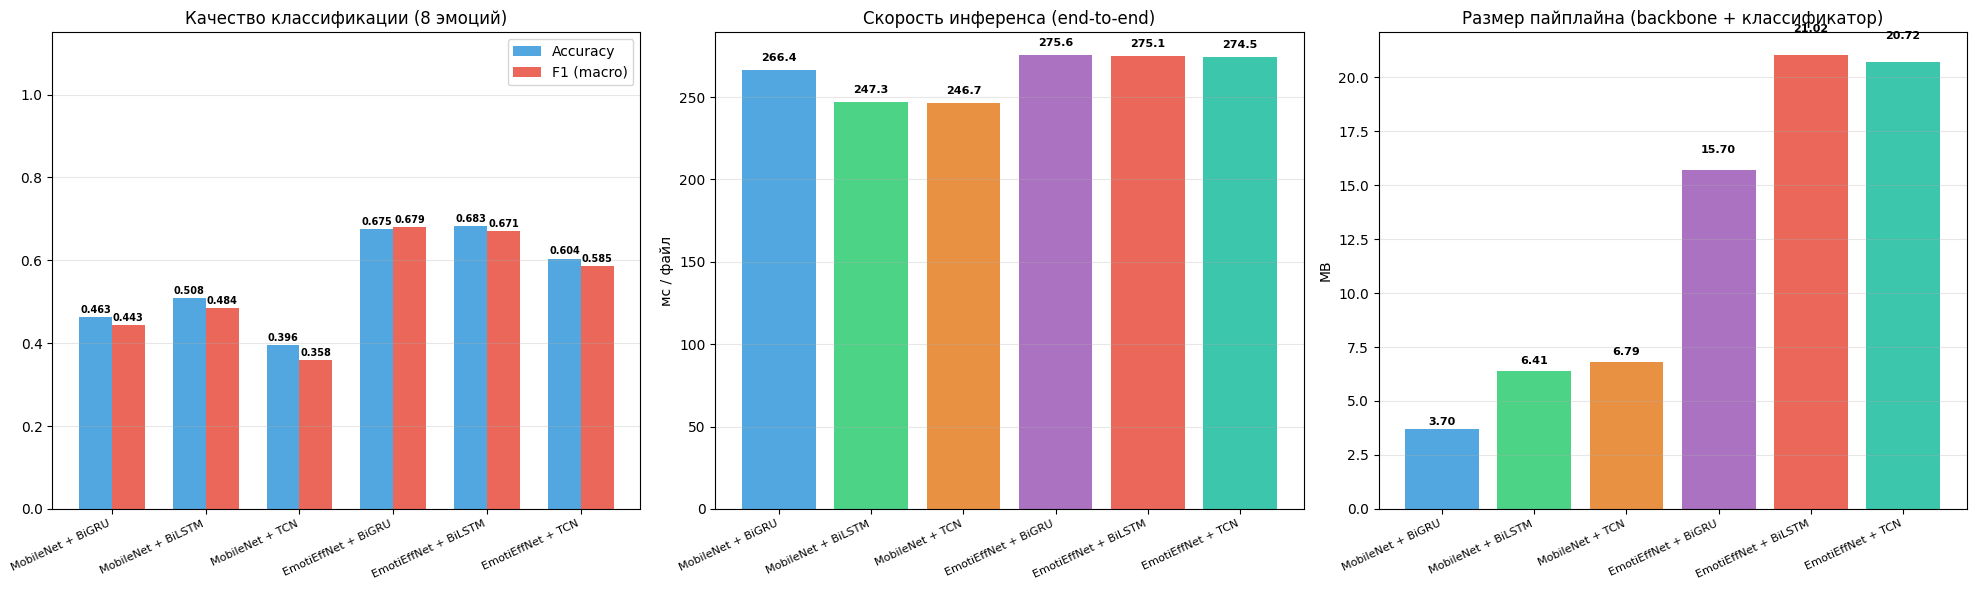

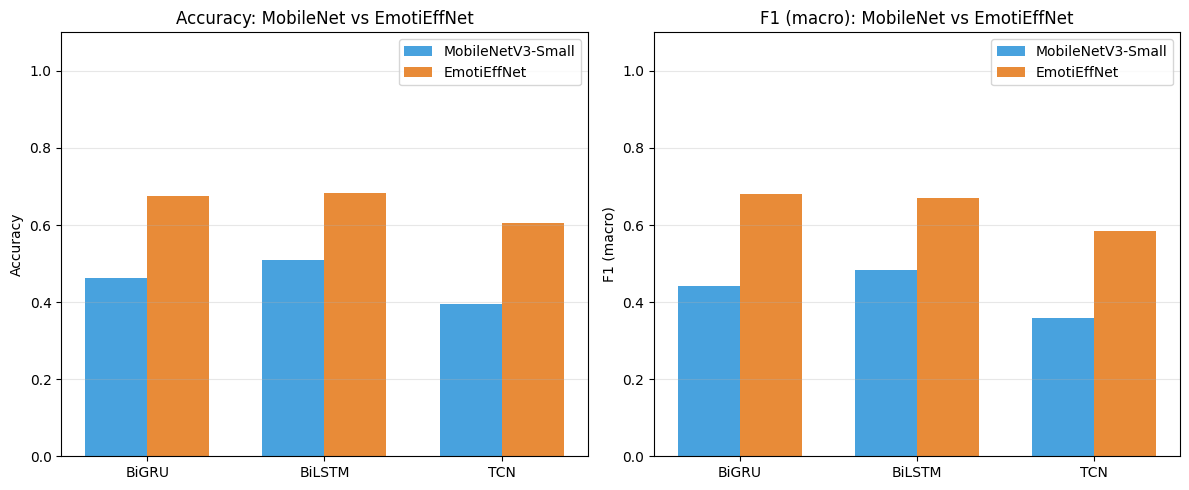

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model_names = df["Модель"].tolist()
x = np.arange(len(model_names))
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

# ── Качество ──
w = 0.35
b1 = axes[0].bar(x - w / 2, df["Accuracy"], w,
                  label="Accuracy", color="#3498db", alpha=0.85)
b2 = axes[0].bar(x + w / 2, df["F1 (macro)"], w,
                  label="F1 (macro)", color="#e74c3c", alpha=0.85)
axes[0].set_ylim(0, 1.15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[0].set_title("Качество классификации (8 эмоций)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for b in list(b1) + list(b2):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                 f"{b.get_height():.3f}", ha="center", fontsize=7, fontweight="bold")

# ── Скорость инференса ──
b3 = axes[1].bar(x, df["Инференс (мс/файл)"], color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[1].set_ylabel("мс / файл")
axes[1].set_title("Скорость инференса (end-to-end)")
axes[1].grid(axis="y", alpha=0.3)
for b in b3:
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.02,
                 f"{b.get_height():.1f}", ha="center", fontsize=8, fontweight="bold")

# ── Размер пайплайна ──
b4 = axes[2].bar(x, df["Пайплайн (MB)"], color=colors, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[2].set_ylabel("MB")
axes[2].set_title("Размер пайплайна (backbone + классификатор)")
axes[2].grid(axis="y", alpha=0.3)
for b in b4:
    axes[2].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.05,
                 f"{b.get_height():.2f}", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

# Попарное сравнение backbone при одинаковой темпоральной агрегации (порядок строк в df: MN×3, затем Eff×3)
fig2, axes_cmp = plt.subplots(1, 2, figsize=(12, 5))
agg_short = ["BiGRU", "BiLSTM", "TCN"]
x2 = np.arange(3)
w2 = 0.35
mn_sl, ef_sl = slice(0, 3), slice(3, 6)
axes_cmp[0].bar(x2 - w2 / 2, df.iloc[mn_sl]["Accuracy"], w2, label="MobileNetV3-Small", color="#3498db", alpha=0.9)
axes_cmp[0].bar(x2 + w2 / 2, df.iloc[ef_sl]["Accuracy"], w2, label="EmotiEffNet", color="#e67e22", alpha=0.9)
axes_cmp[0].set_xticks(x2)
axes_cmp[0].set_xticklabels(agg_short)
axes_cmp[0].set_ylim(0, 1.1)
axes_cmp[0].set_ylabel("Accuracy")
axes_cmp[0].set_title("Accuracy: MobileNet vs EmotiEffNet")
axes_cmp[0].legend()
axes_cmp[0].grid(axis="y", alpha=0.3)

axes_cmp[1].bar(x2 - w2 / 2, df.iloc[mn_sl]["F1 (macro)"], w2, label="MobileNetV3-Small", color="#3498db", alpha=0.9)
axes_cmp[1].bar(x2 + w2 / 2, df.iloc[ef_sl]["F1 (macro)"], w2, label="EmotiEffNet", color="#e67e22", alpha=0.9)
axes_cmp[1].set_xticks(x2)
axes_cmp[1].set_xticklabels(agg_short)
axes_cmp[1].set_ylim(0, 1.1)
axes_cmp[1].set_ylabel("F1 (macro)")
axes_cmp[1].set_title("F1 (macro): MobileNet vs EmotiEffNet")
axes_cmp[1].legend()
axes_cmp[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()